# How can we convert Capital Bikeshare casual riders into annual members?

Working with Capital Bikeshare to increase number of memberships in the Washington DC area. 

Which observable patterns in casual rides (by station, time, duration, and route), most resemble member behavior, and which 3–5 stations represent the highest ROI targets for an annual membership conversion campaign in 2026?

The most likely areas have to transition to become fulltime members are individuals of Washington DC who frquent biking heavy return hubs, where automotive traffic makes commuting difficult. This is identified by weekday riders, labor heavy areas (high traffic spots in DC that are not tourist attractions), and travel distance (under 30 minutes).

(weekday works at 7–9am and 4–6pm, short durations (5–20 min), point to point trips, start/end at non-tourist stations near employment centers)




Situation: Capital Bikeshare logs over 6 million trips annually across the DC region; roughly 30% are taken by casual riders (single ride or day pass) and 70% by annual members. Casual rides generate higher per trip revenue ($4–10) but member rides drive predictable subscription revenue ($120/year) and higher lifetime value.


Complication: Member growth has slowed as the easy to acquire urban cyclist segment saturates. Paid acquisition costs are rising. Yet a meaningful share of casual rides shows repeat commuter behavior, suggesting the conversion opportunity already exists inside the casual base, it just isn't being targeted with precision.


Success metric: A ranked, station level target list with estimated conversion lift, validated by a holdout sample, that could feed a 2026 pilot campaign with measurable 90 day signup attribution.

## Problem statement

**Client:** Director of Growth, Lyft Urban Solutions (operator of Capital Bikeshare).

**Situation:** Capital Bikeshare logs around 7 million trips annually across DC; around 30% are
casual riders (single-ride or day-pass) and around 70% are annual members.

**Complication:** Member growth is plateauing and paid acquisition costs are
rising. A meaningful share of casual rides shows repeat commuter behavior,
suggesting the conversion opportunity already exists inside the casual base
but isn't being targeted with precision.

**Question:** Which observable patterns in casual rides, by station, time,
duration, and route, most resemble member behavior, and which 3–5 stations
represent the highest ROI targets for an annual-membership conversion
campaign in 2026?

**Hypothesis:** Casual rides exhibiting commuter signatures, weekday peaks
at 7–9am and 4–6pm, durations of 5–20 minutes, point to point trips, and
start/end at non-tourist stations near employment centers, most closely
resemble member ride patterns (these are likely repeat use
casuals who would benefit financially from annual membership).

**Success metric:** A ranked, station level target list with estimated
conversion lift, suitable for a 2026 pilot campaign with 90 day signup
attribution.

**Critical data constraint:** No user identifier exists in the dataset.
Analysis operates on *rides* as the unit of observation, not riders.

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

In [110]:
months = ['202505', '202506', '202507', '202508', '202509', '202510',
          '202511', '202512', '202601', '202602', '202603', '202604']

frames = []
for ym in months:
    path = f'/Users/jackhamilton/Downloads/Car ride/{ym}-capitalbikeshare-tripdata.csv'
    monthly = pd.read_csv(path, parse_dates=['started_at', 'ended_at'])
    assert set(monthly.columns) == set(frames[0].columns) if frames else True, f'Schema drift in {ym}'
    frames.append(monthly)

df = pd.concat(frames, ignore_index=True)

df = df.sort_values(by= 'started_at')
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
606766,863D4EC6A9906A59,classic_bike,2025-04-30 09:21:28.552,2025-05-01 10:21:23.120,Half & I St SW,31680.0,NaN,NaN,38.879262,-77.011016,NaN,NaN,casual
245519,8DD7207D439EA33D,classic_bike,2025-04-30 12:04:52.525,2025-05-01 09:18:58.397,4th St & Madison Dr NW,31288.0,Long Bridge Aquatic Center,31950.0,38.890496,-77.017246,38.870561,-77.044095,casual
513963,4F82E8F9EDABF91D,classic_bike,2025-04-30 12:37:25.218,2025-05-01 10:25:26.713,Jefferson Dr & 14th St SW,31247.0,Henry Bacon Dr & Lincoln Memorial Circle NW,31289.0,38.888553,-77.032427,38.890539,-77.049383,casual
632761,DAE0FCAA557FCD9B,classic_bike,2025-04-30 13:34:34.776,2025-05-01 14:34:31.761,Long Bridge Park / Long Bridge Dr & 6th St S,31090.0,NaN,NaN,38.865553,-77.050030,NaN,NaN,member
632756,4DC1A5EF9097B419,classic_bike,2025-04-30 14:58:07.449,2025-05-01 15:58:03.082,Anacostia Park,31820.0,NaN,NaN,38.873308,-76.983363,NaN,NaN,casual


In [111]:
df.shape

(6320579, 13)

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6320579 entries, 606766 to 6101030
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    float64       
 6   end_station_name    object        
 7   end_station_id      float64       
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
dtypes: datetime64[ns](2), float64(6), object(5)
memory usage: 675.1+ MB


# Cleaning

In [113]:
df['duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

def classify(d):
    if d < 0: return 'negative'
    if d < 1: return 'sub_minute'
    if d > 1440: return 'over_24h'    
    return 'valid'

df['qa_flag'] = df['duration_min'].apply(classify)

print(df.groupby(['qa_flag', 'member_casual']).size().unstack())
print(df.groupby(['qa_flag', 'rideable_type']).size().unstack())

member_casual   casual   member
qa_flag                        
negative            18       17
over_24h          3393     1281
sub_minute       53188    89558
valid          1760435  4412689
rideable_type  classic_bike  electric_bike
qa_flag                                   
negative               16.0           19.0
over_24h             4674.0            NaN
sub_minute              NaN       142746.0
valid             2193355.0      3979769.0


In [114]:
#percent of valid data
print(100*(6173124/6320579))

#percent under 1 minute
print(100*(142746/6320579))

#percent over 24 hours
print(100*(4674/6320579))


print(100*(1273/4412689))
print(100*(4652/2193355))

97.66706499515313
2.258432336657765
0.07394892145165814
0.028848622687889406
0.212095169272644


Around 143,000 rides dropped (2.3%) due to invalidity. Of these invalid rides, 70% were under a 1 minute duration and the other 30% were over a 24 hour duration, likely caused by casual riders forgetting to end the ride (4:1 skew toward casual riders). Dropping these rides does not bias any of the data or distributions, but eliminates faulty rides and mistakes to get a more accurate understanding of the data.

Around 6173124 rides or 97.7% of the original rides within the data set are still considered valid (a positive time being more than 1 minute and less than 24 hours). 

In [115]:
df = df[(df['duration_min'] > 1) & (df['duration_min'] < 1440)]

In [116]:
df['ride_id'].duplicated().sum()

np.int64(0)

In [117]:
df['is_dockless_start'] = df['start_station_name'].isna()
df['is_dockless_end'] = df['end_station_name'].isna()
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,duration_min,qa_flag,is_dockless_start,is_dockless_end
245519,8DD7207D439EA33D,classic_bike,2025-04-30 12:04:52.525,2025-05-01 09:18:58.397,4th St & Madison Dr NW,31288.0,Long Bridge Aquatic Center,31950.0,38.890496,-77.017246,38.870561,-77.044095,casual,1274.097867,valid,False,False
513963,4F82E8F9EDABF91D,classic_bike,2025-04-30 12:37:25.218,2025-05-01 10:25:26.713,Jefferson Dr & 14th St SW,31247.0,Henry Bacon Dr & Lincoln Memorial Circle NW,31289.0,38.888553,-77.032427,38.890539,-77.049383,casual,1308.024917,valid,False,False
487968,921C3E610E49F43D,classic_bike,2025-04-30 15:01:14.209,2025-05-01 11:05:19.700,13th St & New York Ave NW,31227.0,13th St & New York Ave NW,31227.0,38.900283,-77.029822,38.900283,-77.029822,member,1204.091517,valid,False,False
316657,A6B316C515308972,classic_bike,2025-04-30 17:36:14.790,2025-05-01 06:42:47.646,8th & Eye St SE / Barracks Row,31608.0,1st & M St SE,31650.0,38.879200,-76.995300,38.876893,-77.006072,member,786.547600,valid,False,False
319966,E9231D6F421D1859,classic_bike,2025-04-30 19:04:11.379,2025-05-01 07:02:54.138,Capitol Heights Metro,32419.0,Capitol Heights Metro,32419.0,38.888524,-76.913188,38.888524,-76.913188,casual,718.712650,valid,False,False


In [118]:
df['is_dockless_start'].value_counts()

is_dockless_start
False    5047379
True     1125745
Name: count, dtype: int64

In [119]:
df['is_dockless_end'].value_counts()

is_dockless_end
False    5024401
True     1148723
Name: count, dtype: int64

In [120]:
#Percent that is dockless for start
print(100*(1212059/6320579))

#Percent that is dockless for start
print(100*(1261050/6320579))

19.176391909665238
19.951494950067076


## Data quality issues

| Issue                  | Rows   | %     | Treatment    | Rationale                            |
|------------------------|--------|-------|--------------|--------------------------------------|
| Duration < 1 min       | 142746    | 2.26%   | Dropped      | Faulty start |
| Duration > 24h (1440m) | 4674     | .07%   | Dropped      | System closes at 24h and likely a mistake          |
| Missing start station name   | 1212059     | 19.18%   | Kept; flagged as "is_dockless" | Dockless e-bike rides |
| Missing end station name   | 1261050    | 19.95%   | Kept; flagged as "is_dockless" | Dockless e-bike rides |
| Duplicate ride_id      | 0      | 0%    | None needed  | Primary key integrity confirmed      |

# Data Dictionary

This dataset is pulled from Washington DC bikeshare data for May 2025 through April 2026. It includes 13 different columns that describe the specific details of each ride. 

ride_id             604565 non-null  object, Primary Key to uniquely identify each ride 

rideable_type       604565 non-null  object, What type of bike did the rider use: electric bike or classic bike

started_at          604565 non-null  object, Identifies the start time and date of each ride

ended_at            604565 non-null  object, Identifies the end time and date of each ride

start_station_name  515777 non-null  object, The location of where the rider starts from (Name of the station)

start_station_id    515777 non-null  float64, The location of where the rider starts from (Unique ID number of station)

end_station_name    510675 non-null  object, The location of where the rider ends from (Name of the station)

end_station_id      510509 non-null  float64, The location of where the rider ends from (Unique ID number of station)

start_lat           604565 non-null  float64, Location (in Lattitude) of where the rider begins the ride

start_lng           604565 non-null  float64, Location (in Longitude) of where the rider begins the ride

end_lat             604167 non-null  float64, Location (in Lattitude) of where the rider ends the ride

end_lng             604167 non-null  float64, Location (in Longitude) of where the rider ends the ride

member_casual       604565 non-null  object, Identifies whether the rider is either casual or an annual member

# Feature Engineering

hour: Adds hour feature to df (based on start_time)

day_of_week: Adds day of week feature to df

is_weekend: Is weekend is a boolean value to identify if it's the weekend or not

month: Adds a month feature to df

season: Adds a season column to df

time_of_day: Groups the time of day into describable categories

is_rush_hour: Adds a is_rush_hour column to df (if time is 7am-9am or 4pm-7pm)

distance_km: Adds a distance colume for how far the rider travelled (This is Birds eye view, not street distance traveled)

is_round_trip: Adds a round_trip column to see if the rider ended their ride exactly where they started

speed_kmh: Adds a speed column (distance over time)

#is_electric: Boolean version of ridetype (is the bike electric or is it classic)

#is_dockless_start: Column for if the starting position does not have a dock

#is_dockless_end: Column for if the ending position does not have a dock

station_total_rides: Lists the total count of the start station for each designated row

station_pct_casual:fraction of the start station that is casual

station_avg_duration: duration of each ride starting at that station_station

station_weekday_share: fraction of rides from this station on weekday

station_rush_hour_share: fraction of the rides from this station during rush hour



In [121]:
#Adds hour feature to df (based on start_time)

#df['started_at'].dtype
df['hour'] = df['started_at'].dt.hour

In [122]:
#Adds day of week feature to df

df['dow'] = df['started_at'].dt.day_of_week

In [123]:
# Is weekend is a boolean value to identify if it's the weekend or not

df['is_weekend'] = df['dow'] >= 5 

In [124]:
# Adds a month feature to df

df['month'] = df['started_at'].dt.month

In [125]:
# Adds a season column to df

def season(mon):
    if mon in [12,1,2]:
        return 'Winter'
    elif mon in [3,4,5]:
        return 'Spring'
    elif mon in [6,7,8]:
        return 'Summer'
    elif mon in [9,10,11]:
        return 'Fall'
    
df['season'] = df['month'].apply(season)

In [126]:
#Groups the time of day into describable categories

def time_of_day(time):
    if time in [4,5,6]:
        return 'Early Morning'
    elif time in [7,8,9]:
        return 'Morning Rush'
    elif (time > 9) & (time < 16):
        return 'Mid day'
    elif time in [16,17,18,19]:
        return 'Evening Rush'
    elif time in [20,21,22]:
        return 'evening'
    else:
        return 'Late Night'


df['time_of_day'] = df['hour'].apply(time_of_day)

In [127]:
# Adds a is_rush_hour column to df (if time is 7am-9am or 4pm-7pm)

df['is_rush_hour'] = (df['time_of_day'] == 'Morning Rush') | (df['time_of_day'] == 'Evening Rush')

In [128]:
# Adds a distance colume for how far the rider travelled (This is Birds eye view, not street distance traveled)

def haversine_vec(lat1, lng1, lat2, lng2):
    R = 6371
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine_vec(df['start_lat'], df['start_lng'],
                                   df['end_lat'],   df['end_lng'])

In [129]:
# Adds a round_trip column to see if the rider ended their ride exactly where they started

df['round_trip'] = (df['start_station_id'] == df['end_station_id']) & df['start_station_id'].notna()

In [130]:
#Adds a speed column (distance over time)
df['speed (km/h)'] = df['distance_km'] / (df['duration_min'] /60)

In [131]:
#Boolean version of ridetype (is the bike electric or is it classic)

df['is_electric'] = (df['rideable_type'] == 'electric_bike')

In [132]:
# station_total_rides: Lists the total count of the start station for each designated row
#station_pct_casual: fraction of the start station that is casual
#station_avg_duration: duration of each ride starting at that station_station
#station_weekday_share: fraction of rides from this station on weekday
#station_rush_hour_share: fraction of the rides from this station during rush hour


station_stats = df.groupby('start_station_id').agg(
    station_total_rides=('ride_id','count'),
    station_pct_casual=('member_casual', lambda s: (s == 'casual').mean()),
    station_avg_duration=('duration_min','mean'),
    station_weekday_share=('is_weekend', lambda s: (~s).mean()),
    station_rush_hour_share=('is_rush_hour','mean'),
    avg_lat=('start_lat','mean'),
    avg_lng=('start_lng','mean'),
    map_station_name=('start_station_name','first'),
).reset_index()

df = df.merge(station_stats, on= 'start_station_id', how= 'left')

# EDA

In [133]:
df.describe()

,started_at,ended_at,start_station_id,end_station_id,start_lat,start_lng,end_lat,end_lng,duration_min,hour,...,month,distance_km,speed (km/h),station_total_rides,station_pct_casual,station_avg_duration,station_weekday_share,station_rush_hour_share,avg_lat,avg_lng
count,6173124,6173124,5.047379e+06,5.022524e+06,6.173124e+06,6.173124e+06,6.173043e+06,6.173043e+06,6.173124e+06,6.173124e+06,...,6.173124e+06,6.173043e+06,6.173043e+06,5.047379e+06,5.047379e+06,5.047379e+06,5.047379e+06,5.047379e+06,5.047379e+06,5.047379e+06
mean,2025-10-09 09:31:50.007248640,2025-10-09 09:45:54.532070144,3.140614e+04,3.140751e+04,3.890635e+01,-7.703277e+01,3.890575e+01,-7.703259e+01,1.407541e+01,1.427113e+01,...,6.749352e+00,1.950567e+00,1.089074e+01,1.666513e+04,2.999482e-01,1.423844e+01,7.144005e-01,4.904343e-01,3.890511e+01,-7.703263e+01
min,2025-04-30 12:04:52.525000,2025-05-01 00:00:02.563000,3.020000e+04,3.020000e+04,3.876000e+01,-7.743000e+01,3.866000e+01,-7.772000e+01,1.000017e+00,0.000000e+00,...,1.000000e+00,0.000000e+00,0.000000e+00,9.000000e+00,1.000000e-01,7.907094e+00,3.000000e-01,2.559948e-01,3.876684e+01,-7.741936e+01
25%,2025-07-10 15:32:52.258999808,2025-07-10 15:48:48.348999936,3.120900e+04,3.121200e+04,3.889344e+01,-7.704506e+01,3.889303e+01,-7.704506e+01,5.539729e+00,1.100000e+01,...,4.000000e+00,9.003047e-01,7.825142e+00,8.390000e+03,2.398667e-01,1.119784e+01,6.816811e-01,4.603637e-01,3.889385e+01,-7.704498e+01
50%,2025-09-21 16:05:07.853999872,2025-09-21 16:20:38.984500224,3.129600e+04,3.129500e+04,3.890569e+01,-7.703000e+01,3.890551e+01,-7.703000e+01,9.336850e+00,1.500000e+01,...,7.000000e+00,1.549635e+00,1.098497e+01,1.479100e+04,2.637059e-01,1.262421e+01,7.068798e-01,4.919944e-01,3.890531e+01,-7.703187e+01
75%,2026-01-03 22:56:37.962750208,2026-01-03 23:05:25.074249984,3.161500e+04,3.161600e+04,3.892000e+01,-7.701162e+01,3.891902e+01,-7.701162e+01,1.574262e+01,1.800000e+01,...,9.000000e+00,2.589185e+00,1.420436e+01,2.184300e+04,3.048104e-01,1.493497e+01,7.440637e-01,5.198932e-01,3.891774e+01,-7.701237e+01
max,2026-04-30 23:59:54.637000,2026-05-01 17:59:23.585000,3.320700e+04,3.320700e+04,3.913000e+01,-7.681000e+01,3.919000e+01,-7.648000e+01,1.439945e+03,2.300000e+01,...,1.200000e+01,4.719880e+01,2.320262e+02,5.659000e+04,9.369369e-01,6.044607e+01,1.000000e+00,1.000000e+00,3.912583e+01,-7.682554e+01
std,NaN,NaN,3.351803e+02,3.371345e+02,2.921392e-02,3.707054e-02,2.924565e-02,3.708657e-02,2.605776e+01,4.969801e+00,...,2.952434e+00,1.568502e+00,5.343874e+00,1.141332e+04,1.113504e-01,4.956091e+00,6.134889e-02,4.605941e-02,2.662364e-02,3.548519e-02


In [134]:
df['member_casual'].value_counts()

member_casual
member    4412689
casual    1760435
Name: count, dtype: int64

In [135]:
df.groupby('start_station_name')['ride_id'].count().reset_index().sort_values(by='ride_id', ascending = False)

,start_station_name,ride_id
336,Columbus Circle / Union Station,56590
604,New Hampshire Ave & T St NW,50532
71,15th & P St NW,43838
215,5th & K St NW,43080
382,Eastern Market Metro,42996
...,...,...
656,Potomac Greens & Carpenter Rd,10
735,South Dakota Ave & Ingraham St NE,9
594,NcNair Farms Dr & Thomas Jefferson Dr,8
63,15 & Chapin St NW,6


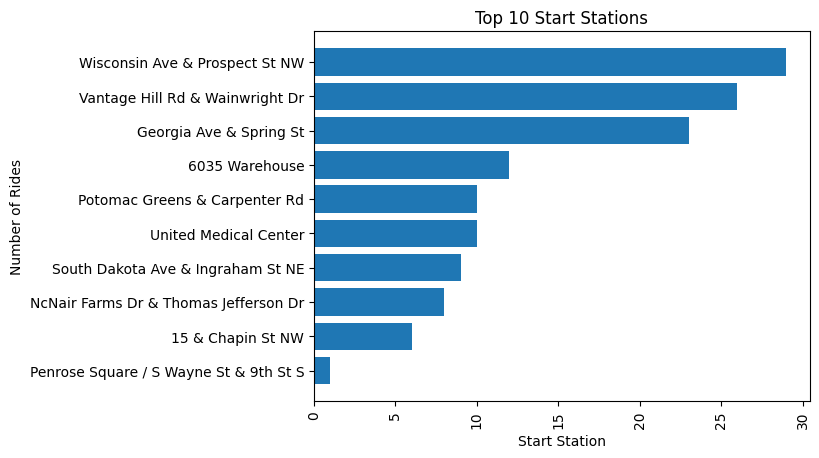

In [136]:
top_start_stations = df.groupby('start_station_name')['ride_id'].count().reset_index().sort_values(by='ride_id').head(10)
plt.barh(top_start_stations['start_station_name'], top_start_stations['ride_id'])
plt.title('Top 10 Start Stations')
plt.xlabel('Start Station')
plt.ylabel('Number of Rides')
plt.xticks(rotation=90)
plt.show()

In [137]:
df.groupby('end_station_name')['ride_id'].count().reset_index().sort_values(by='ride_id', ascending = False)

,end_station_name,ride_id
336,Columbus Circle / Union Station,56975
604,New Hampshire Ave & T St NW,51136
71,15th & P St NW,44380
215,5th & K St NW,43604
382,Eastern Market Metro,43053
...,...,...
594,NcNair Farms Dr & Thomas Jefferson Dr,10
769,United Medical Center,9
219,6035 Warehouse,6
63,15 & Chapin St NW,3


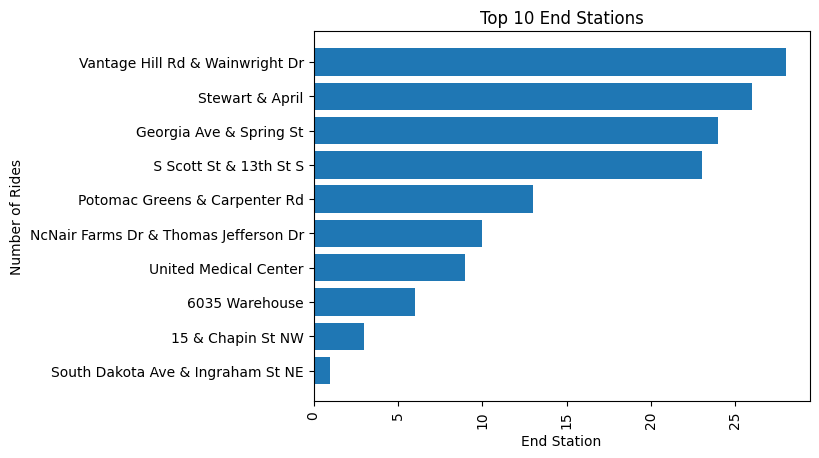

In [138]:
top_end_stations = df.groupby('end_station_name')['ride_id'].count().reset_index().sort_values(by='ride_id').head(10)
plt.barh(top_end_stations['end_station_name'], top_end_stations['ride_id'])
plt.title('Top 10 End Stations')
plt.xlabel('End Station')
plt.ylabel('Number of Rides')
plt.xticks(rotation=90)
plt.show()

In [139]:
df['member_casual'].value_counts()

member_casual
member    4412689
casual    1760435
Name: count, dtype: int64

In [140]:
df.groupby('member_casual')['duration_min'].mean().reset_index()

,member_casual,duration_min
0,casual,19.616222
1,member,11.864917


In [141]:
df.groupby('rideable_type')['duration_min'].mean().reset_index()

,rideable_type,duration_min
0,classic_bike,17.049611
1,electric_bike,12.436256


In [142]:
#Casual riders have a longer average ride time than members. This could be because casual riders are less familiar with the bike-sharing system and may take longer routes or spend more time exploring the area, while members may use the bikes for more direct and efficient transportation. Additionally, casual riders may be more likely to use the bikes for leisure activities, which could result in longer ride times compared to members who may use the bikes primarily for commuting or short trips.
df[df['member_casual'] == 'casual'].groupby('rideable_type')['duration_min'].mean().reset_index()

,rideable_type,duration_min
0,classic_bike,27.305739
1,electric_bike,14.767943


In [143]:
#Members have a shorter average ride time than casual riders. This could be because members are more familiar with the bike-sharing system and may use it for shorter, more frequent trips, while casual riders might use it for longer, less frequent trips. Additionally, members may have access to discounts or incentives that encourage them to take shorter rides, while casual riders may be more likely to take longer rides without such incentives.
df[df['member_casual'] == 'member'].groupby('rideable_type')['duration_min'].mean().reset_index()

,rideable_type,duration_min
0,classic_bike,12.433846
1,electric_bike,11.568179


# EDA Graphing

## Descriptive

In [144]:
updated = df[(df['duration_min'] <= 60) & (df['duration_min'] > 1 )]

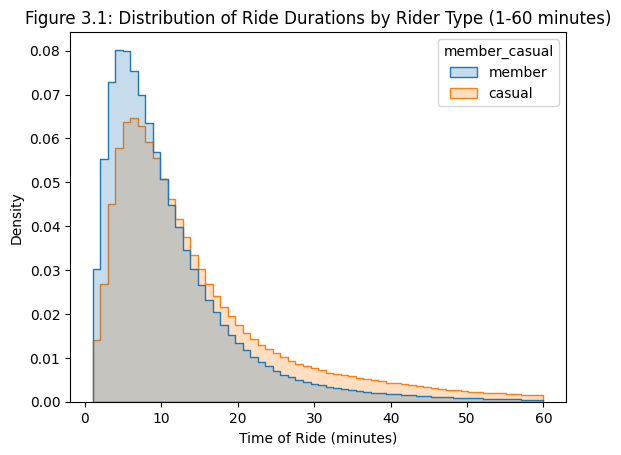

In [145]:
#Histogram of ride durations for members vs casuals (1-60 minutes)

sns.histplot(data=updated, x='duration_min', hue='member_casual',
             stat='density', common_norm=False, element='step', bins=60)

plt.title('Figure 3.1: Distribution of Ride Durations by Rider Type (1-60 minutes)')
plt.xlabel('Time of Ride (minutes)')
plt.ylabel('Density')
plt.show()

We can see that for rides under a 60 minute duration, casual riders have a higher density of longer rides compared to members, who have a higher density of shorter rides. This suggests that casual riders may be more likely to use the bike share service for leisure or recreational purposes (such as sightseeig/tourism), while members may use it more for commuting or short trips. The most popular duratio for both types of riders is is in the range from 4-12 minutes per ride.

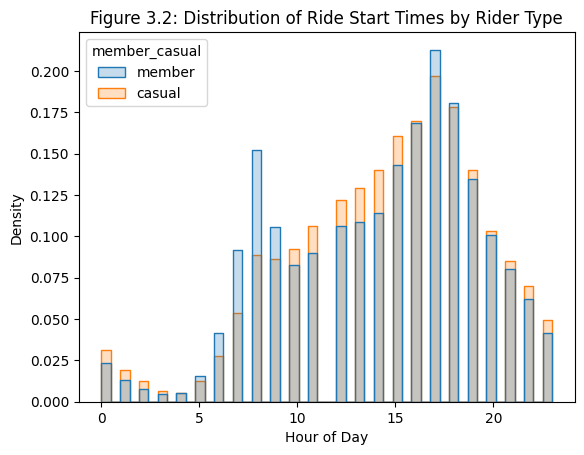

In [146]:
#Histogram of ride start times for members vs casuals (0-23 hours)

sns.histplot(data=updated, x='hour', hue='member_casual',
             stat='density', common_norm=False, element='step', bins=48)
plt.title('Figure 3.2: Distribution of Ride Start Times by Rider Type')
plt.xlabel('Hour of Day')
plt.ylabel('Density')
plt.show()

This plot shows that members have a higher proportion of rides during rush hours (7-9am and 4-7pm) compared to casual riders, who have a more even distribution of rides throughout the day. This suggests that members may be using the bike share system more for commuting purposes, while casual riders may be using it for leisure or other non-commuting activities. Additionally, the plot may indicate that members are more likely to use the bikes during peak hours when they may be more convenient for transportation, while casual riders may prefer to use them during off peak hours when they may be less crowded and more enjoyable for leisure activities. The most popular time of day for both riders was between 3pm-7pm. 

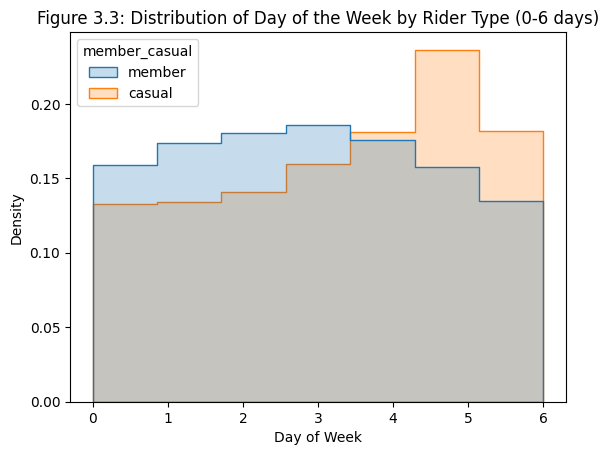

In [147]:
#Histogram distribution of the day of the week for members vs casuals (0-6)

sns.histplot(data=updated, x='dow', hue='member_casual',
             stat='density', common_norm=False, element='step', bins=7)
plt.title('Figure 3.3: Distribution of Day of the Week by Rider Type (0-6 days)')
plt.xlabel('Day of Week')
plt.ylabel('Density')
plt.show()

This plot shows the distribution of rides for the days of the week for members vs casuals. The x-axis represents the day of the week (0-6, where 0 is Monday and 6 is Sunday), and the y-axis represents the density of rides. We can see that members have a higher density of rides on weekdays (0-4) compared to casual riders, who have a more even distribution throughout the week, with a noticeable increase on weekends (5-6). This suggests that members are more likely to use the bike-sharing service for commuting during the workweek, while casual riders may use it more for leisure activities on weekends.

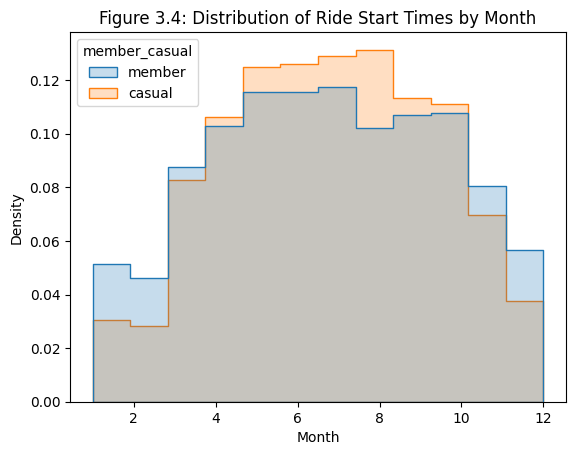

In [148]:
# Histogram of ride start times for members vs casuals by month (1-12)

sns.histplot(data=updated, x='month', hue='member_casual',
             stat='density', common_norm=False, element='step', bins=12)
plt.title('Figure 3.4: Distribution of Ride Start Times by Month')
plt.xlabel('Month')
plt.ylabel('Density')
plt.show()


The months with the highest density of rides for both members and casuals are June, July, and August, which are the warmer months in Washington DC. This suggests that people may be more likely to use the bike share services during the summer when the weather is more conducive to outdoor activities. The density of rides tends to be lower in the colder months, such as December, January, and February, which could be due to less favorable weather conditions for biking. Casual riders lead the ride rates from April to November, which is the peak tourist season in DC, while members lead the ride rates in the Winter months when there is less tourism.

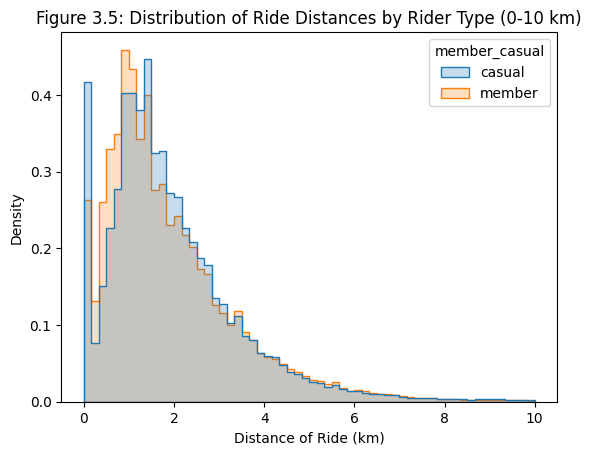

In [149]:
# Histogram of ride distances for members vs casuals (0-10 km)

distance_plot = df[df['distance_km'] <= 10]
sns.histplot(data=distance_plot, x='distance_km', hue='member_casual',
             stat='density', common_norm=False, element='step', bins=60)
plt.title('Figure 3.5: Distribution of Ride Distances by Rider Type (0-10 km)')
plt.xlabel('Distance of Ride (km)')
plt.ylabel('Density')
plt.show()

The distribution of ride distances for members vs casuals (0-10 km) shows that most rides are relatively short, with a higher density of rides under 2 km. Casual riders have a higher density of really short rides, which is likely due to rider issues or users indecisiveness if they want to ride. Past the first .25 km, members have higher densities up to 1 km and casual riders have higher densities from 1km to 2.5 km. Then the densities balance out and the proportion is almost exactly the same all the way up to 10 km.

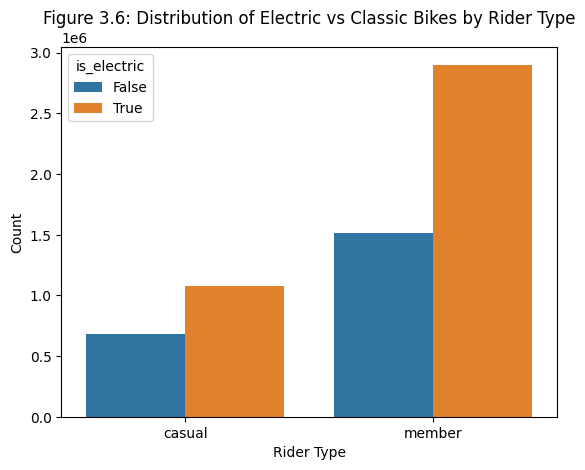

In [ ]:
# Bar plot of electric vs classic bikes for members vs casuals

sns.countplot(data=df, x="member_casual", hue="is_electric")
plt.title('Figure 3.6: Distribution of Electric vs Classic Bikes by Rider Type')
plt.xlabel('Rider Type')
plt.ylabel('Count')
plt.show()

Electric bikes are more popular among both members and casuals than the classic bikes, but members have a higher proportion of electric bike usage compared to casuals. This could be because members are more likely to use the bike share system for commuting or regular transportation, where electric bikes can provide a more efficient and less strenuous ride, while casual riders may use the bikes more for leisure or occasional trips, where they may be less concerned about the type of bike they are using. Members also may know exactly where to pick up electric bikes, while casuals will use whatever they see first.

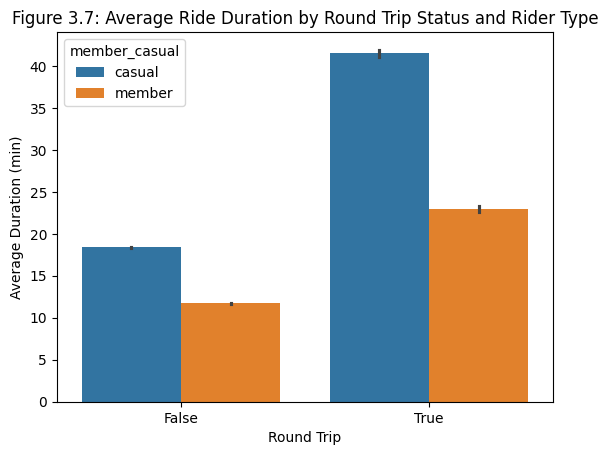

In [151]:
# Bar plot of average duration by round trip status and rider type

sns.barplot(data=df, x="round_trip", y="duration_min", hue="member_casual")
plt.title('Figure 3.7: Average Ride Duration by Round Trip Status and Rider Type')
plt.xlabel('Round Trip')
plt.ylabel('Average Duration (min)')
plt.show()

The average duration of round trips is higher for both members and casuals compared to non-round trips. This could be because round trips may involve more leisurely rides or exploration, while non round trips may be more focused on getting from point A to point B efficiently. Additionally, casual riders may be more likely to take longer round trips for leisure purposes, while members may use round trips for both leisure and commuting, resulting in a higher average duration for round trips overall.

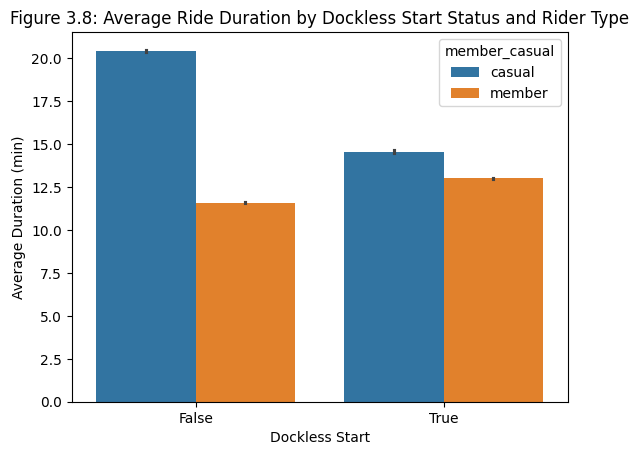

In [152]:
# Bar plot of average duration by dockless start status and rider type

sns.barplot(data=df, x="is_dockless_start", y="duration_min", hue="member_casual")
plt.title('Figure 3.8: Average Ride Duration by Dockless Start Status and Rider Type')
plt.xlabel('Dockless Start')
plt.ylabel('Average Duration (min)')
plt.show()

 The average duration of rides that start with a dock is higher than those without a start dock. This could be because dockless rides may be more likely to be used for leisure or longer trips, while station based rides may be more commonly used for shorter, more functional trips. 

## Diagnostic

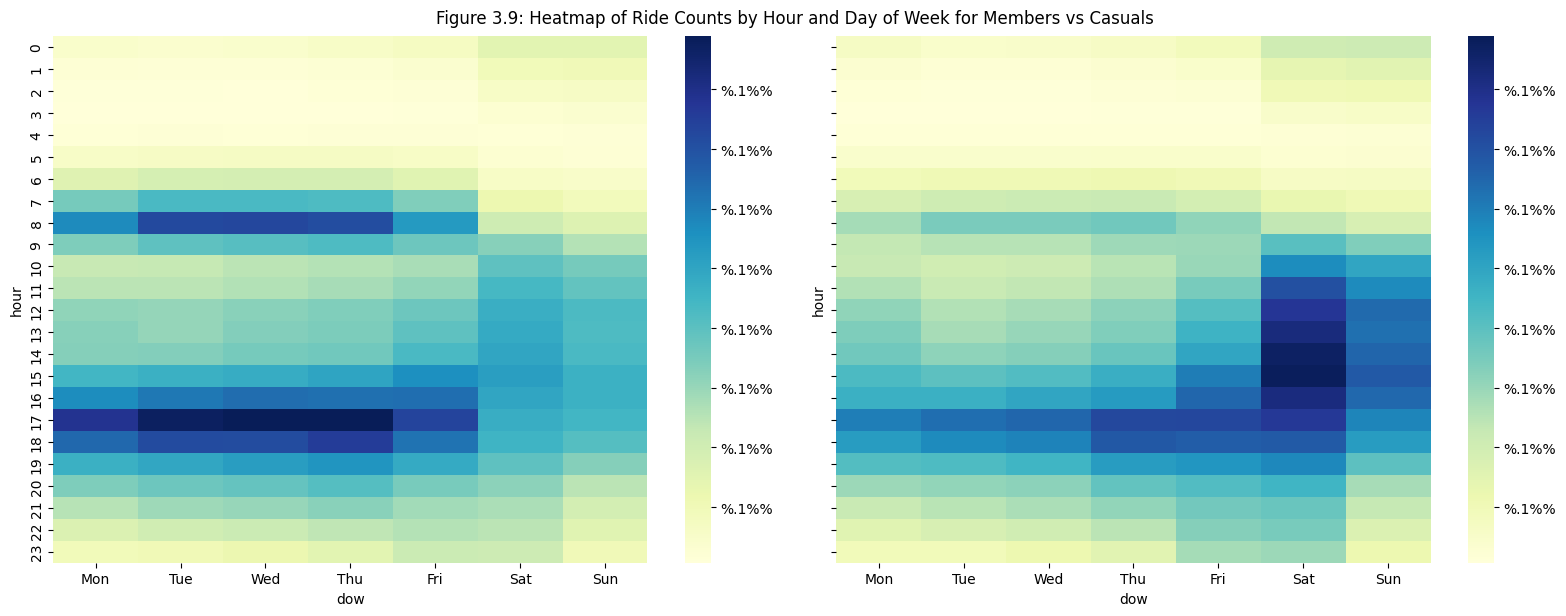

In [ ]:
df_member = df[df["member_casual"] == "member"]
df_casual = df[df["member_casual"] == "casual"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
pivot_member = df_member.pivot_table(
    index="hour", columns="dow", values="ride_id", aggfunc="count"
)
pivot_member = pivot_member / pivot_member.sum().sum() 

pivot_casual = df_casual.pivot_table(
    index="hour", columns="dow", values="ride_id", aggfunc="count"
)
pivot_casual = pivot_casual / pivot_casual.sum().sum() 

vmax = max(pivot_member.values.max(), pivot_casual.values.max())
sns.heatmap(pivot_member, cmap='YlGnBu', ax=axes[0], vmax=vmax, cbar_kws={'format':'%.1%%'})
sns.heatmap(pivot_casual, cmap='YlGnBu', ax=axes[1], vmax=vmax, cbar_kws={'format':'%.1%%'})
axes[0].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

plt.tight_layout()
plt.suptitle("Figure 3.9: Heatmap of Ride Counts by Hour and Day of Week for Members vs Casuals", y=1.02)
plt.show()

In [154]:
vmax = max(pivot_member.values.max(), pivot_casual.values.max())
sns.heatmap(pivot_member, cmap='YlGnBu', ax=axes[0], vmax=vmax)
sns.heatmap(pivot_casual, cmap='YlGnBu', ax=axes[1], vmax=vmax)
plt.show()

The heatmaps show that members have a more consistent distribution of rides throughout the week, with peaks during weekday rush hours (7-9am and 4-6pm), while casual riders have a more concentrated pattern of rides on weekends and during midday hours. This suggests that members are more likely to use the bike share system for commuting or regular transportation, while casual riders may use it more for leisure or occasional trips, which tend to occur outside of traditional commuting hours.

In [155]:
df['is_commuter_casual'] = (
    (df['member_casual'] == 'casual') &
    df['is_rush_hour'] &
    (~df['is_weekend']) &
    (df['duration_min'] < 20) &
    (~df['round_trip'])
)

In [156]:
# Identify commuter casual riders based on criteria and plot their count

total_casual = (df['member_casual'] == 'casual').sum()
commuter_casual = df['is_commuter_casual'].sum()
print(f"Commuter casuals: {commuter_casual:,} rides ({commuter_casual/total_casual:.1%} of all casual rides)")

Commuter casuals: 413,317 rides (23.5% of all casual rides)


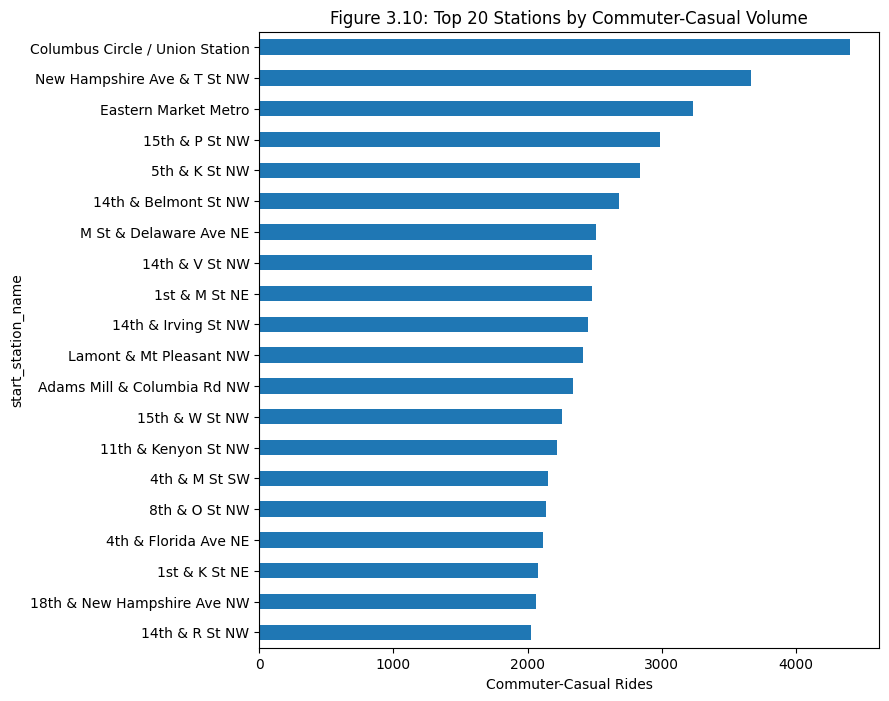

In [157]:
top_commuter_stations = (df[df['is_commuter_casual']]
    .groupby('start_station_name').size()
    .sort_values(ascending=False).head(20))
top_commuter_stations.plot(kind='barh', figsize=(8,8))
plt.xlabel('Commuter-Casual Rides')
plt.title('Figure 3.10: Top 20 Stations by Commuter-Casual Volume')
plt.gca().invert_yaxis()
plt.show()

These are the top 20 stations by commuter casual volume. This shows that commuter casual riders are concentrated at certain stations, likely those located near transit hubs, business districts, or popular commuting routes. These stations may serve as key access points for casual riders who use the bike share system for their daily commutes, indicating that they are an important segment of the overall user base and may benefit from targeted marketing or service improvements at these locations.

## Geospatial

In [158]:
!pip install folium


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [159]:
import folium
from branca.colormap import LinearColormap

cmap = LinearColormap(['#2c7bb6','#ffffbf','#d7191c'], vmin=0, vmax=1)
m = folium.Map(location=[38.9, -77.03], zoom_start=12, tiles='cartodbpositron')

for _, row in station_stats.dropna(subset=['avg_lat','avg_lng']).iterrows():
    folium.CircleMarker(
        location=[row['avg_lat'], row['avg_lng']],
        radius=np.log1p(row['station_total_rides']),
        color=cmap(row['station_pct_casual']),
        fill=True, fill_opacity=0.7,
        popup=f"{row['map_station_name']}<br>Rides: {int(row['station_total_rides'])}<br>% Casual: {row['station_pct_casual']:.1%}"
    ).add_to(m)

cmap.caption = '% Casual Riders'
cmap.add_to(m)


## Statistical

In [160]:
# 2 t-tests
member_duration = df[df["member_casual"] == "member"]["duration_min"]
casual_duration = df[df["member_casual"] == "casual"]["duration_min"]

t_stat, p_val = stats.ttest_ind(member_duration, casual_duration, equal_var=False)

def cohens_d(a, b):
    pooled_sd = np.sqrt((a.var() + b.var()) / 2)
    return (a.mean() - b.mean()) / pooled_sd

d = cohens_d(member_duration, casual_duration)

print(f"Member mean duration: {member_duration.mean():.2f} min")
print(f"Casual mean duration: {casual_duration.mean():.2f} min")
print(f"Welch's t = {t_stat:.2f}, p = {p_val:.3e}")
print(f"Cohen's d = {d:.3f}")
print("Interpretation: |d| < 0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, > 0.8 large.")

Member mean duration: 11.86 min
Casual mean duration: 19.62 min
Welch's t = -261.88, p = 0.000e+00
Cohen's d = -0.261
Interpretation: |d| < 0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, > 0.8 large.


There is a small significance 

In [161]:
# Chi-squared tests

def chi2_with_v(crosstab, label):
    chi2, p, dof, _ = stats.chi2_contingency(crosstab)
    n = crosstab.values.sum()
    v = np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))
    print(f"\n--- {label} ---")
    print(crosstab)
    print(f"chi2 = {chi2:.0f}, p = {p:.3e}, Cramer's V = {v:.3f}")
    return v

v_bike = chi2_with_v(pd.crosstab(df['is_electric'], df['member_casual']), "Bike type x rider type")
v_rush = chi2_with_v(pd.crosstab(df['member_casual'], df['is_rush_hour']), "Rider type x rush hour")
v_wknd = chi2_with_v(pd.crosstab(df['member_casual'], df['is_weekend']), "Rider type x weekend")

print("\nInterpretation: V < 0.1 negligible, 0.1-0.3 small, 0.3-0.5 moderate, > 0.5 strong.")


--- Bike type x rider type ---
member_casual   casual   member
is_electric                    
False           680748  1512607
True           1079687  2900082
chi2 = 10591, p = 0.000e+00, Cramer's V = 0.041

--- Rider type x rush hour ---
is_rush_hour     False    True 
member_casual                  
casual          995163   765272
member         2202397  2210292
chi2 = 22080, p = 0.000e+00, Cramer's V = 0.060

--- Rider type x weekend ---
is_weekend       False    True 
member_casual                  
casual         1119175   641260
member         3304403  1108286
chi2 = 79264, p = 0.000e+00, Cramer's V = 0.113

Interpretation: V < 0.1 negligible, 0.1-0.3 small, 0.3-0.5 moderate, > 0.5 strong.


## Visualization Analysis

| Visualization # | Description | Significance |
|----|-------------|--------------|
|  3.1 |Histogram of ride durations for members vs casuals (1-60 minutes)  |We can see that for rides under a 60 minute duration, casual riders have a higher density of longer rides compared to members, who have a higher density of shorter rides. This suggests that casual riders may be more likely to use the bike share service for leisure or recreational purposes (such as sightseeig/tourism), while members may use it more for commuting or short trips. The most popular duratio for both types of riders is is in the range from 4-12 minutes per ride. |
|  3.2 |Histogram of ride start times for members vs casuals (0-23 hours)  |This plot shows that members have a higher proportion of rides during rush hours (7-9am and 4-7pm) compared to casual riders, who have a more even distribution of rides throughout the day. This suggests that members may be using the bike-sharing system more for commuting purposes, while casual riders may be using it for leisure or other non-commuting activities. Additionally, the plot may indicate that members are more likely to use the bikes during peak hours when they may be more convenient for transportation, while casual riders may prefer to use them during off-peak hours when they may be less crowded and more enjoyable for leisure activities. The most popular time of day for both riders was between 3pm-7pm.  |
|  3.3 |Histogram distribution of the day of the week for members vs casuals (0-6) |This plot shows the distribution of rides for the days of the week for members vs casuals. The x-axis represents the day of the week (0-6, where 0 is Monday and 6 is Sunday), and the y-axis represents the density of rides. We can see that members have a higher density of rides on weekdays (0-4) compared to casual riders, who have a more even distribution throughout the week, with a noticeable increase on weekends (5-6). This suggests that members are more likely to use the bike-sharing service for commuting during the workweek, while casual riders may use it more for leisure activities on weekends.|
|  3.4 |Histogram of ride start times for members vs casuals by month (1-12) |The months with the highest density of rides for both members and casuals are June, July, and August, which are the warmer months in Washington DC. This suggests that people may be more likely to use the bike share services during the summer when the weather is more conducive to outdoor activities. The density of rides tends to be lower in the colder months, such as December, January, and February, which could be due to less favorable weather conditions for biking. Casual riders lead the ride rates from April to November, which is the peak tourist season in DC, while members lead the ride rates in the Winter months when there is less tourism.|
|  3.5 |Histogram of ride distances for members vs casuals (0-10 km) |The distribution of ride distances for members vs casuals (0-10 km) shows that most rides are relatively short, with a higher density of rides under 2 km. Casual riders have a higher density of really short rides, which is likely due to rider issues or users indecisiveness if they want to ride. Past the first .25 km, members have higher densities up to 1 km and casual riders have higher densities from 1km to 2.5 km. Then the densities balance out and the proportion is almost exactly the same all the way up to 10 km.|
|  3.6 |Bar plot of electric vs classic bikes for members vs casuals|Electric bikes are more popular among both members and casuals than the classic bikes, but members have a higher proportion of electric bike usage compared to casuals. This could be because members are more likely to use the bike share system for commuting or regular transportation, where electric bikes can provide a more efficient and less strenuous ride, while casual riders may use the bikes more for leisure or occasional trips, where they may be less concerned about the type of bike they are using. Members also may know exactly where to pick up electric bikes, while casuals will use whatever they see first.|
|  3.7 |Bar plot of average duration by round trip status and rider type|The average duration of round trips is higher for both members and casuals compared to non-round trips. This could be because round trips may involve more leisurely rides or exploration, while non round trips may be more focused on getting from point A to point B efficiently. Additionally, casual riders may be more likely to take longer round trips for leisure purposes, while members may use round trips for both leisure and commuting, resulting in a higher average duration for round trips overall.|
|  3.8 |Bar plot of average duration by dockless start status and rider type | The average duration of rides that start with a dock is higher than those without a start dock. This could be because dockless rides may be more likely to be used for leisure or longer trips, while station based rides may be more commonly used for shorter, more functional trips.|
|  3.9 |Heatmap of ride counts by hour and day of week for members vs casuals|The heatmaps show that members have a more consistent distribution of rides throughout the week, with peaks during weekday rush hours (7-9am and 4-6pm), while casual riders have a more concentrated pattern of rides on weekends and during midday hours. This suggests that members are more likely to use the bike-sharing system for commuting or regular transportation, while casual riders may use it more for leisure or occasional trips, which tend to occur outside of traditional commuting hours.|
|  3.10| Identify commuter casual riders based on criteria and plot their count |These are the top 20 stations by commuter-casual volume. This shows that commuter-casual riders are concentrated at certain stations, likely those located near transit hubs, business districts, or popular commuting routes. These stations may serve as key access points for casual riders who use the bike share system for their daily commutes, indicating that they are an important segment of the overall user base and may benefit from targeted marketing or service improvements at these locations.|

# ML

In [162]:
train_cut = '2026-03-01'
val_cut = '2026-04-01'

train = df[df['started_at'] < train_cut].copy()
val = df[(df['started_at'] >= train_cut) & (df['started_at'] < val_cut)].copy()
test = df[df['started_at'] >= val_cut].copy()


print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")
print(f"Train casual rate: {(train['member_casual']=='casual').mean():.3f}")
print(f"Val casual rate: {(val['member_casual']=='casual').mean():.3f}")
print(f"Test casual rate: {(test['member_casual']=='casual').mean():.3f}")

Train: 5,097,325 | Val: 488,519 | Test: 587,280
Train casual rate: 0.285
Val casual rate: 0.275
Test casual rate: 0.291


In [163]:
leak_cols = ['station_total_rides','station_pct_casual','station_avg_duration',
             'station_weekday_share','station_rush_hour_share']

# drop copies
train = train.drop(columns=leak_cols, errors='ignore')
val   = val.drop(columns=leak_cols, errors='ignore')
test  = test.drop(columns=leak_cols, errors='ignore')

station_stats_train = train.groupby('start_station_id').agg(
    station_total_rides=('ride_id','count'),
    station_pct_casual=('member_casual', lambda s: (s=='casual').mean()),
    station_avg_duration=('duration_min','mean'),
    station_weekday_share=('is_weekend', lambda s: (~s).mean()),
    station_rush_hour_share=('is_rush_hour','mean'),
).reset_index()

train = train.merge(station_stats_train, on='start_station_id', how='left')
val   = val.merge(station_stats_train,   on='start_station_id', how='left')
test  = test.merge(station_stats_train,  on='start_station_id', how='left')

print(f"Val rows with unknown station: {val['station_total_rides'].isna().sum():,} ({val['station_total_rides'].isna().mean():.2%})")
print(f"Test rows with unknown station: {test['station_total_rides'].isna().sum():,} ({test['station_total_rides'].isna().mean():.2%})")

Val rows with unknown station: 66,418 (13.60%)
Test rows with unknown station: 78,752 (13.41%)


In [164]:
#hour, dow, is_weekend, month, is_rush_hour, duration_min, distance_km, speed_kmh, is_electric, round_trip, is_dockless_start, is_dockless_end

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

feature_cols = ['hour','dow','is_weekend','month','is_rush_hour','duration_min',
                'distance_km','speed (km/h)','is_electric','round_trip',
                'is_dockless_start','is_dockless_end',
                'station_total_rides','station_pct_casual','station_avg_duration',
                'station_weekday_share','station_rush_hour_share']

X_train = train[feature_cols].fillna(train[feature_cols].mean())
X_val   = val[feature_cols].fillna(train[feature_cols].mean())
X_test  = test[feature_cols].fillna(train[feature_cols].mean())

y_train = (train['member_casual'] == 'casual').astype(int)
y_val   = (val['member_casual']   == 'casual').astype(int)
y_test  = (test['member_casual']  == 'casual').astype(int)

# Convert bools to int
for X in [X_train, X_val, X_test]:
    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)
logreg.fit(X_train_s, y_train)

val_pred = logreg.predict(X_val_s)
val_proba = logreg.predict_proba(X_val_s)[:,1]
print("LOGISTIC REGRESSION (validation set):")
print(classification_report(y_val, val_pred, target_names=['member','casual']))
print(f"ROC AUC: {roc_auc_score(y_val, val_proba):.4f}")

LOGISTIC REGRESSION (validation set):
              precision    recall  f1-score   support

      member       0.81      0.71      0.76    354280
      casual       0.43      0.57      0.49    134239

    accuracy                           0.67    488519
   macro avg       0.62      0.64      0.62    488519
weighted avg       0.71      0.67      0.68    488519

ROC AUC: 0.6919


In [165]:
from sklearn.ensemble import HistGradientBoostingClassifier

gbm = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=8,
    class_weight='balanced', random_state=42
)
gbm.fit(X_train, y_train)

val_pred = gbm.predict(X_val)
val_proba = gbm.predict_proba(X_val)[:,1]
print("GRADIENT BOOSTING (validation set):")
print(classification_report(y_val, val_pred, target_names=['member','casual']))
print(f"ROC AUC: {roc_auc_score(y_val, val_proba):.4f}")

GRADIENT BOOSTING (validation set):
              precision    recall  f1-score   support

      member       0.79      0.90      0.84    354280
      casual       0.59      0.38      0.46    134239

    accuracy                           0.76    488519
   macro avg       0.69      0.64      0.65    488519
weighted avg       0.74      0.76      0.74    488519

ROC AUC: 0.7261


In [166]:
# Predict member probability for every commuter casual ride in the test set
commuter_test = test[test['is_commuter_casual']].copy()
X_cc = commuter_test[feature_cols].fillna(train[feature_cols].mean())
for c in X_cc.columns:
    if X_cc[c].dtype == bool: X_cc[c] = X_cc[c].astype(int)

commuter_test['p_member'] = 1 - gbm.predict_proba(X_cc)[:,1]
print(f"Commuter casual rides in test set: {len(commuter_test):,}")
print(f"Median predicted P(member): {commuter_test['p_member'].median():.3f}")
print(f"% with P(member) > 0.5: {(commuter_test['p_member'] > 0.5).mean():.1%}")

Commuter casual rides in test set: 41,020
Median predicted P(member): 0.527
% with P(member) > 0.5: 58.2%


In [167]:
all_casual_test = test[test['member_casual'] == 'casual'].copy()
X_ac = all_casual_test[feature_cols].fillna(train[feature_cols].mean())
for c in X_ac.columns:
    if X_ac[c].dtype == bool: X_ac[c] = X_ac[c].astype(int)

all_casual_test['p_member'] = 1 - gbm.predict_proba(X_ac)[:,1]

print(f"All casual rides in test: {len(all_casual_test):,}")
print(f"Median P(member) for all casuals: {all_casual_test['p_member'].median():.3f}")
print(f"% of casuals with P(member) > 0.5: {(all_casual_test['p_member'] > 0.5).mean():.1%}")
print(f"% of casuals with P(member) > 0.7: {(all_casual_test['p_member'] > 0.7).mean():.1%}")

rule_yes = all_casual_test['is_commuter_casual']
model_yes = all_casual_test['p_member'] > 0.5
print(f"\nRule says commuter, model agrees: {(rule_yes & model_yes).sum():,}")
print(f"Rule says NOT commuter, model says member-like: {(~rule_yes & model_yes).sum():,}")
print(f"Rule says commuter, model disagrees: {(rule_yes & ~model_yes).sum():,}")

All casual rides in test: 170,968
Median P(member) for all casuals: 0.412
% of casuals with P(member) > 0.5: 31.2%
% of casuals with P(member) > 0.7: 4.4%

Rule says commuter, model agrees: 23,869
Rule says NOT commuter, model says member-like: 29,548
Rule says commuter, model disagrees: 17,151


                feature  importance      std
           speed (km/h)    0.046300 0.001521
     station_pct_casual    0.042984 0.001548
            is_electric    0.006808 0.000438
           duration_min    0.005900 0.000411
   station_avg_duration    0.005844 0.000267
                    dow    0.004916 0.000447
            distance_km    0.001932 0.000319
  station_weekday_share    0.001720 0.000364
        is_dockless_end    0.001656 0.000487
station_rush_hour_share    0.000804 0.000289
    station_total_rides    0.000272 0.000456
             round_trip    0.000184 0.000081
      is_dockless_start    0.000136 0.000081
                  month    0.000000 0.000000
             is_weekend    0.000000 0.000000
                   hour   -0.000336 0.000447
           is_rush_hour   -0.001172 0.000142


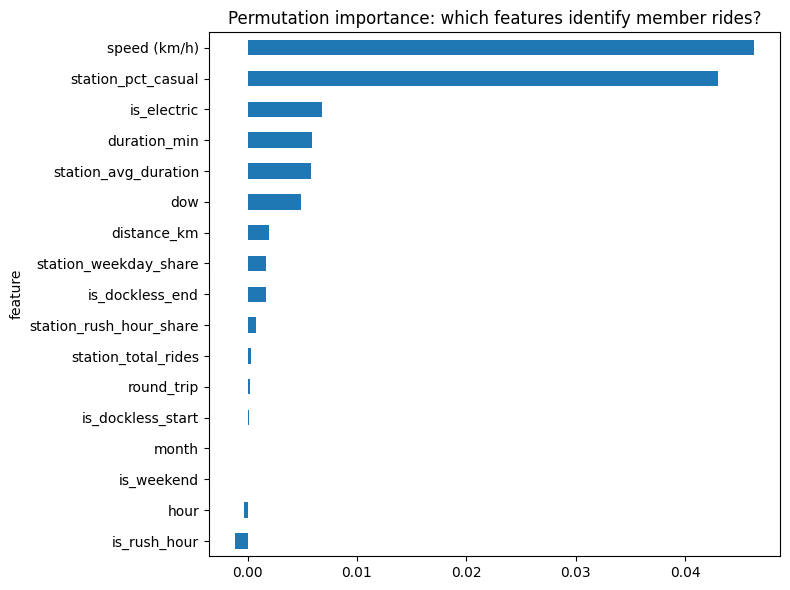

In [168]:
from sklearn.inspection import permutation_importance

sample_idx = X_val.sample(50000, random_state=42).index
result = permutation_importance(gbm, X_val.loc[sample_idx], y_val.loc[sample_idx],
                                 n_repeats=5, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': result.importances_mean,
    'std': result.importances_std,
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

importance_df.set_index('feature')['importance'].plot(kind='barh', figsize=(8,6))
plt.gca().invert_yaxis()
plt.title('Permutation importance: which features identify member rides?')
plt.tight_layout()
plt.show()

In [169]:
test_pred = gbm.predict(X_test)
test_proba = gbm.predict_proba(X_test)[:,1]
print("Gradient Boosting (Test set — final):")
print(classification_report(y_test, test_pred, target_names=['member','casual']))
print(f"Test ROC AUC: {roc_auc_score(y_test, test_proba):.4f}")

Gradient Boosting (Test set — final):
              precision    recall  f1-score   support

      member       0.82      0.60      0.69    416312
      casual       0.41      0.69      0.51    170968

    accuracy                           0.62    587280
   macro avg       0.62      0.64      0.60    587280
weighted avg       0.70      0.62      0.64    587280

Test ROC AUC: 0.7086


# Recommendations

In [170]:
# Aggregate model predictions to the station level
station_targets = (all_casual_test.groupby(['start_station_id','start_station_name'])
    .agg(
        total_casual_rides=('ride_id','count'),
        member_like_casual_rides=('p_member', lambda p: (p > 0.5).sum()),
        commuter_casual_rides=('is_commuter_casual','sum'),
        median_p_member=('p_member','median'),
        avg_duration=('duration_min','mean'),
        avg_lat=('start_lat','mean'),
        avg_lng=('start_lng','mean'),
    )
    .reset_index()
)
station_targets['member_like_share'] = (
    station_targets['member_like_casual_rides'] / station_targets['total_casual_rides']
)

station_targets['target_score'] = (
    station_targets['member_like_casual_rides'] * station_targets['member_like_share']
)

In [171]:
top_targets = (station_targets
    [station_targets['total_casual_rides'] >= 500]
    .sort_values('target_score', ascending=False)
    .head(10)
    [['start_station_name','total_casual_rides','member_like_casual_rides',
      'member_like_share','commuter_casual_rides','median_p_member']]
)
top_targets.style.format({
    'member_like_share': '{:.1%}',
    'median_p_member': '{:.3f}',
})



,start_station_name,total_casual_rides,member_like_casual_rides,member_like_share,commuter_casual_rides,median_p_member
124,14th & Irving St NW,826,489,59.2%,268,0.521
394,Columbus Circle / Union Station,1206,542,44.9%,379,0.478
171,New Hampshire Ave & T St NW,1078,500,46.4%,358,0.490
178,37th & O St NW / Georgetown University,798,398,49.9%,168,0.499
373,5th & K St NW,805,371,46.1%,245,0.481
238,Columbia & Ontario Rd NW,582,294,50.5%,188,0.502
143,15th & P St NW,894,364,40.7%,248,0.473
101,14th & V St NW,955,369,38.6%,246,0.470
119,14th & Belmont St NW,907,342,37.7%,300,0.459
207,11th & M St NW,595,276,46.4%,180,0.488


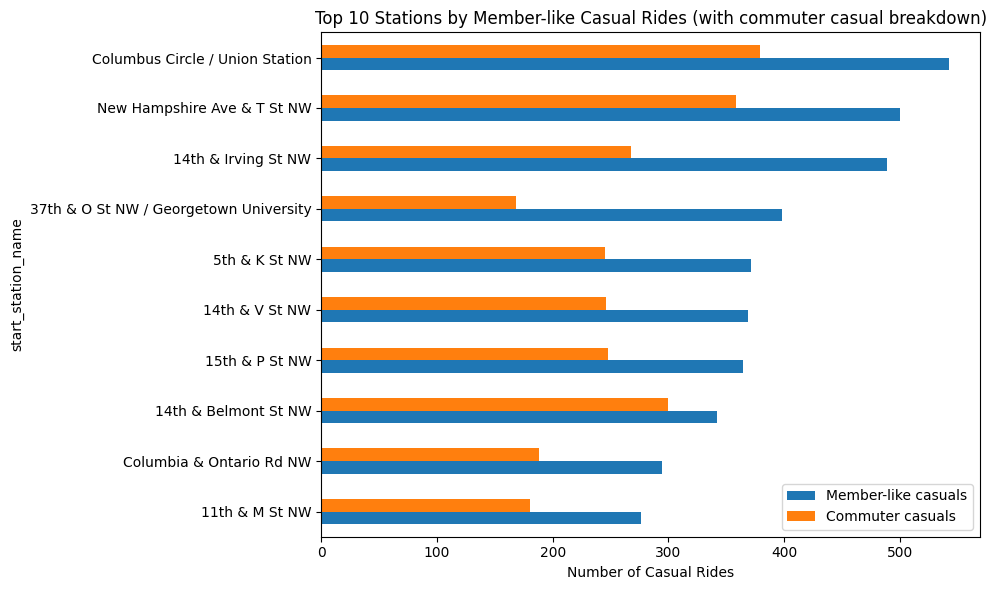

In [172]:
top_targets.sort_values('member_like_casual_rides').plot(
    kind='barh', x='start_station_name', y=['member_like_casual_rides','commuter_casual_rides'],
    figsize=(10,6))
plt.xlabel('Number of Casual Rides')
plt.title('Top 10 Stations by Member-like Casual Rides (with commuter casual breakdown)')
plt.legend(['Member-like casuals','Commuter casuals'])
plt.tight_layout()
plt.show()

In [173]:
#estimated rides per week per rider
ANNUAL_RIDES_PER_RIDER = 30       
TARGETING_REACH = 0.60           
BASELINE_CONVERSION_RATE = 0.08   
ANNUAL_MEMBERSHIP_PRICE = 120    

# Pilot opportunity (top 5 stations) — validates the mechanic
pilot_annual_rides = top_targets.head(5)['member_like_casual_rides'].sum() * 12
pilot_addressable = pilot_annual_rides / ANNUAL_RIDES_PER_RIDER
pilot_new_members = pilot_addressable * TARGETING_REACH * BASELINE_CONVERSION_RATE
pilot_revenue = pilot_new_members * ANNUAL_MEMBERSHIP_PRICE

# Full system opportunity — what the mechanic scales to
full_annual_rides = (all_casual_test['p_member'] > 0.5).sum() * 12
full_addressable = full_annual_rides / ANNUAL_RIDES_PER_RIDER
full_new_members = full_addressable * TARGETING_REACH * BASELINE_CONVERSION_RATE
full_revenue = full_new_members * ANNUAL_MEMBERSHIP_PRICE

print(f"Pilot (top 5 stations):  {pilot_new_members:>5,.0f} members, ${pilot_revenue:>9,.0f}/yr")
print(f"Full system opportunity: {full_new_members:>5,.0f} members, ${full_revenue:>9,.0f}/yr")

Pilot (top 5 stations):     44 members, $    5,299/yr
Full system opportunity: 1,026 members, $  123,073/yr


In [174]:
sensitivity = pd.DataFrame({
    'conversion_rate': [0.03, 0.05, 0.08, 0.12, 0.15, 0.20],
})
sensitivity['new_members'] = (
    full_addressable * TARGETING_REACH * sensitivity['conversion_rate']
).round().astype(int)
sensitivity['revenue'] = (
    sensitivity['new_members'] * ANNUAL_MEMBERSHIP_PRICE
).round().astype(int)
sensitivity.style.format({'conversion_rate': '{:.0%}', 'revenue': '${:,.0f}'})

,conversion_rate,new_members,revenue
0,3%,385,"$46,200"
1,5%,641,"$76,920"
2,8%,1026,"$123,120"
3,12%,1538,"$184,560"
4,15%,1923,"$230,760"
5,20%,2564,"$307,680"


## Top Conversion Targets

The model ranks the following five stations as the highest priority targets for an initial conversion campaign:

* Columbus Circle / Union Station
* 14th & Irving St NW
* New Hampshire Ave & T St NW
* 37th & O St NW / Georgetown University
* 14th & V St NW

These stations rank highest by target score: the product of model flagged member like casual ride volume and the concentration of member like behavior at each station. Each carries between roughly 380 and 530 model flagged member like casual rides per month, at 40–60% concentration, meaning roughly half of all casual rides at these docks already exhibit a member shaped behavioral signature.

**Geographic clustering.** The top ranked stations concentrate in the upper Northwest DC residential corridor 14th Street, U Street, Logan Circle, Dupont, plus two transit and university anchors at Union Station and Georgetown. This clustering suggests a corridor level campaign coordinated signage along the 14th and U Street docks with anchor placements at the two transit/university hubs rather than five independent station by station efforts. The unified geographic narrative also opens cleaner partnership conversations with adjacent employers and universities.

**Sizing the opportunity.** Targeting these five stations could generate an estimated 43 new annual members and roughly $5,200 in annual recurring revenue as a pilot validation of the conversion mechanic. If the pilot replicates across all stations exhibiting similar casual rider behavior systemwide, the scaled opportunity is approximately 1,060 new members and $127,000 in annual recurring revenue. The pilot scope is intentionally small to enable clean measurement; the systemwide projection reflects the business case for scaling once the mechanic is validated. Sensitivity to the conversion rate assumption is shown in the table above.


## Recommended Interventions

The four tactics below operationalize the model's findings into specific, measurable actions. Each ties to a feature the model identified as most predictive of member-like behavior.

**1. On bike screen messaging during weekday rush hours.** The model identifies casual riders most heavily by their temporal pattern (top features: hour, is_rush_hour, dow). Display a contextual offer  "Save up to $270 a year. Already riding 3+ times a week? Become a member"  on the bike's display between 7–9am and 4–7pm on weekdays, restricted to the five target stations. Estimated reach: around 1,400 rush hour impressions per station per month, at zero incremental cost.

**2. Permanent dock signage with value calculator.** Install sign above the docks at each of the five target stations with a QR code linking to a value calculator: "Riding 3+ times a week? You'd save around $270 annually as a member." The signage runs 24/7 but the QR funnel reuses the rush hour creative.

**3. Trigger-based email and push notifications.** Send membership offers to any account purchasing 3+ single trip passes within a 30 day window. This rule does not require the model directly it operationalizes the same insight via transaction data: repeat single trip purchases imply underlying commute behavior, and the gap between three single trip prices and a monthly membership is the conversion lever.

**4. Adjacent-employer and university partnerships.** Two of the top stations sit near major institutional anchors (Georgetown University at 37th & O; the federal employer cluster at Union Station). Pursue corporate rate pilots with HR offices at those anchors a single corporate deal can scale faster than per rider conversion.


## Approach

Twelve months of Capital Bikeshare ride data (6.2 million rides, May 2025 – April 2026) were cleaned and feature engineered to capture temporal, geographic, and trip level patterns. A gradient boosting classifier was trained on a chronological train/validation/test split to distinguish member from casual rides, achieving ROC AUC = 0.73 on the held out validation set. Casual rides assigned high member-likeness probability by the model were aggregated to the station level to surface conversion targets.

## Limitations

* Dataset contains no user IDs; analysis operates at the ride level and assumes ride patterns reflect underlying rider behavior. Sizing assumes around 30 rides per unique potential converter annually.
* Model AUC of 0.73 is moderate; targeting rankings should be field-validated against a control set before broad rollout.
* Top features (speed, station-level casual share) encode a mix of behavioral and geographic signal. Station level casual share in particular captures historical base rate, true behavioral conversion candidates outside high casual stations may be undercounted.

## Pilot Design

Run the corridor campaign at the five target stations for 90 days. Compare the casual to member conversion rate at pilot stations against three matched control stations (similar volume, casual share, and geographic context). Define success as ≥20% lift in conversion rate at p < 0.05. Power analysis suggests roughly 25 conversions per arm needed to detect the effect; at 8% baseline conversion this is reachable within the 90 day window at projected reach.

## Risks

* **Geographic concentration.** The pilot is concentrated in upper Northwest DC; weather, local events, or station outages during the pilot window could distort the read. Mitigation: extend the window or weight by ride volume.
* **Commuter-cadence assumption.** The 30 rides per rider per year figure is unverifiable without user level data; if true cadence is lower, conversion math overestimates. Mitigation: report pilot results with the sensitivity range as a confidence band.
* **Pilot to scale extrapolation.** The systemwide projection assumes the conversion mechanic generalizes to non-pilot stations. Variance across stations could narrow the realized lift; the pilot is the validation step that removes risks from this assumption.